In [1]:
# Setup: imports and loading the cleaned datasets produced by notebook 01

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make src/ importable
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Display + reproducibility
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load cleaned datasets produced by notebook 01
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
telco_clean = pd.read_csv(PROCESSED_DIR / "telco_clean.csv")
bank_clean = pd.read_csv(PROCESSED_DIR / "bank_clean.csv")

print(f"Telco cleaned:  {telco_clean.shape[0]:,} rows × {telco_clean.shape[1]} columns")
print(f"Bank cleaned:   {bank_clean.shape[0]:,} rows × {bank_clean.shape[1]} columns")

Telco cleaned:  7,043 rows × 20 columns
Bank cleaned:   10,000 rows × 11 columns


# Customer Churn Risk Modeling — Part 2: Math and Modeling

**Author:** Raya Sergieva  
**Course:** Data Science Final Exam, 2026

This notebook continues the project started in `01_data_loading_and_validation.ipynb`. Notebook 01 covered data loading, cleaning, and exploratory data analysis for two independent customer-churn datasets (IBM Telco and Bank Customer Churn). The cleaned datasets are loaded above from `data/processed/`.

In this notebook we:

1. Formalize the churn-prediction problem mathematically.
2. Lay out the theory behind logistic regression and gradient boosting.
3. Explain why standard accuracy is misleading under class imbalance and which metrics we use instead.
4. Train and compare a linear baseline and a non-linear model on the Telco dataset.
5. Discuss results, limitations, and conclusions.

---

## 1. Mathematical foundations

Before modeling, we formalize the problem and lay out the mathematical objects we will use to fit and evaluate models.

### 1.1 The problem as a probability estimation task

For each customer we observe a feature vector $\mathbf{x} \in \mathbb{R}^d$ (after one-hot encoding categorical variables) and a binary outcome $y \in \{0, 1\}$, where $y = 1$ indicates the customer churned. We assume each $(\mathbf{x}, y)$ pair is drawn independently from some unknown joint distribution $P(\mathbf{x}, y)$.

Our goal is **not** a hard yes/no prediction but an estimate of the conditional probability

$$
p(\mathbf{x}) \;=\; \Pr\bigl(y = 1 \,\big|\, \mathbf{x}\bigr).
$$

This framing matters. Business decisions depend on a probability (the expected value of a retention offer is computed from it), not on a 0/1 label. A model whose probabilities are *calibrated* — customers assigned $p = 0.3$ actually churn 30% of the time — is more useful than a model that is accurate at the default 0.5 threshold but whose probabilities are systematically wrong.

### 1.2 Logistic regression

The linear baseline is logistic regression. It assumes

$$
\Pr(y = 1 \mid \mathbf{x}) \;=\; \sigma\!\left(\mathbf{w}^\top \mathbf{x} + b\right),
\qquad
\sigma(z) \;=\; \frac{1}{1 + e^{-z}},
$$

where $\mathbf{w} \in \mathbb{R}^d$ are the feature weights, $b$ is an intercept, and $\sigma$ is the **logistic (sigmoid) function**, which maps any real number to $(0,1)$. The model is fit by **maximum likelihood**: choose $(\mathbf{w}, b)$ to maximize the likelihood of the observed labels, equivalent to minimizing the **negative log-likelihood**, also called the **log-loss** or **binary cross-entropy**:

$$
\mathcal{L}(\mathbf{w}, b) \;=\; -\frac{1}{N} \sum_{i=1}^{N} \Big[\, y_i \log p(\mathbf{x}_i) + (1 - y_i) \log\bigl(1 - p(\mathbf{x}_i)\bigr) \Big].
$$

Log-loss is the natural loss function for probability estimation because it is a **strictly proper scoring rule**: in expectation, it is minimized only when the predicted probabilities equal the true conditional probabilities $\Pr(y = 1 \mid \mathbf{x})$. This is a stronger property than just "it works" — it means that a model fit by minimizing log-loss is, in the limit of infinite well-distributed data, attempting to estimate true probabilities rather than only ranking customers.

### 1.3 Gradient boosting

Logistic regression is constrained to linear decision boundaries (after the sigmoid). The EDA in notebook 01 revealed several decidedly non-linear relationships — the U-shape in `NumOfProducts`, the inverted-U in `Age`, the price-by-service-mix interaction in the Telco data. A linear model cannot capture these without explicit feature engineering.

Gradient boosting builds an additive model

$$
F(\mathbf{x}) \;=\; \sum_{m=1}^{M} f_m(\mathbf{x}),
$$

where each $f_m$ is a regression tree fit to the *negative gradient of the loss* with respect to the current model's predictions. For binary classification with log-loss, this gradient at example $i$ is $y_i - \sigma\bigl(F(\mathbf{x}_i)\bigr)$ — the residual between the true label and the current predicted probability. Successive trees correct the previous model's errors. The result is non-linear and captures feature interactions automatically, at the cost of interpretability.

### 1.4 Evaluation under class imbalance

Both datasets have a positive-class (churn) rate well below 50% (26.5% for Telco, 20.4% for Bank). Under such imbalance, **accuracy is misleading**: a model that always predicts "no churn" achieves 73.5% accuracy on Telco while being entirely useless for the business problem.

We therefore evaluate using metrics that capture ranking and probability quality:

- **ROC-AUC** (area under the receiver-operating-characteristic curve) is the probability that the model ranks a randomly drawn churner higher than a randomly drawn retainer. It is threshold-independent and equals $0.5$ for random and $1.0$ for perfect.
- **PR-AUC** (area under the precision-recall curve) is more informative than ROC-AUC under heavy class imbalance, because the baseline of PR-AUC equals the positive-class rate (here $\approx 0.265$ and $\approx 0.204$), so improvements over baseline are more visible.
- **Confusion matrix** at a chosen threshold, exposing the precision/recall trade-off in concrete terms.
- **Log-loss** itself, as a measure of probability quality (not just ranking).

We report all of these for each model.

---

## 2. Modeling on the Telco dataset

We now train and compare two models on the Telco dataset: logistic regression and XGBoost. Logistic regression is used as an interpretable linear baseline, while XGBoost is used as a stronger non-linear model.

The preprocessing pipeline uses one-hot encoding for categorical variables and standard scaling for numeric variables. The train/test split is stratified so that the churn rate remains similar in both sets.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    log_loss,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier

# Split features and target
X = telco_clean.drop(columns=["churn"])
y = telco_clean["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y,
)

print(f"Train: {X_train.shape[0]:,} rows  (churn rate: {y_train.mean():.3f})")
print(f"Test:  {X_test.shape[0]:,} rows  (churn rate: {y_test.mean():.3f})")

# Detect numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ]
    )

# Logistic Regression baseline
logreg_pipe = Pipeline(
    steps=[
        ("preprocess", make_preprocessor()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ]
)

logreg_pipe.fit(X_train, y_train)
p_logreg = logreg_pipe.predict_proba(X_test)[:, 1]

# XGBoost model
xgb_pipe = Pipeline(
    steps=[
        ("preprocess", make_preprocessor()),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.1,
                eval_metric="logloss",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_pipe.fit(X_train, y_train)
p_xgb = xgb_pipe.predict_proba(X_test)[:, 1]


def evaluate_model(name, y_true, p_pred, threshold=0.5):
    y_pred = (p_pred >= threshold).astype(int)

    print(f"=== {name} ===")
    print(f"ROC-AUC:   {roc_auc_score(y_true, p_pred):.4f}")
    print(f"PR-AUC:    {average_precision_score(y_true, p_pred):.4f}")
    print(f"Log-loss:  {log_loss(y_true, p_pred):.4f}")
    print(f"Accuracy:  {(y_pred == y_true).mean():.4f}")
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print(classification_report(y_true, y_pred, digits=3))
    print()


evaluate_model("Logistic Regression", y_test, p_logreg)
evaluate_model("XGBoost", y_test, p_xgb)

Train: 5,282 rows  (churn rate: 0.265)
Test:  1,761 rows  (churn rate: 0.265)
=== Logistic Regression ===
ROC-AUC:   0.8462
PR-AUC:    0.6373
Log-loss:  0.4892
Accuracy:  0.7513

Confusion matrix:
[[951 343]
 [ 95 372]]

              precision    recall  f1-score   support

           0      0.909     0.735     0.813      1294
           1      0.520     0.797     0.629       467

    accuracy                          0.751      1761
   macro avg      0.715     0.766     0.721      1761
weighted avg      0.806     0.751     0.764      1761


=== XGBoost ===
ROC-AUC:   0.8295
PR-AUC:    0.6256
Log-loss:  0.4431
Accuracy:  0.7905

Confusion matrix:
[[1161  133]
 [ 236  231]]

              precision    recall  f1-score   support

           0      0.831     0.897     0.863      1294
           1      0.635     0.495     0.556       467

    accuracy                          0.790      1761
   macro avg      0.733     0.696     0.709      1761
weighted avg      0.779     0.790     0.781 

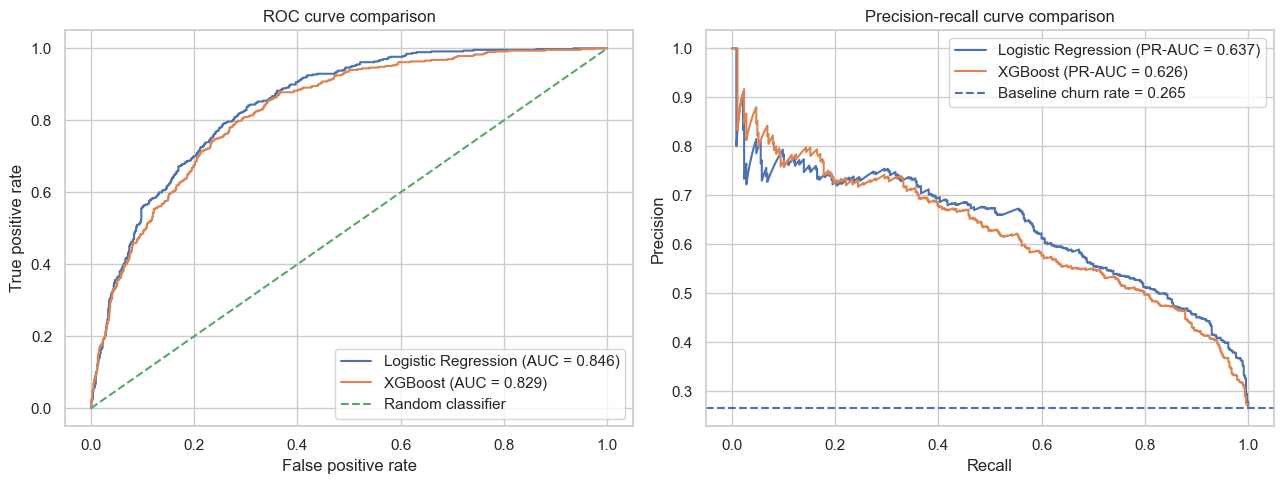

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
for name, probs in [
    ("Logistic Regression", p_logreg),
    ("XGBoost", p_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
axes[0].set_title("ROC curve comparison")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

# Precision-recall curve
baseline = y_test.mean()

for name, probs in [
    ("Logistic Regression", p_logreg),
    ("XGBoost", p_xgb),
]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})")

axes[1].axhline(baseline, linestyle="--", label=f"Baseline churn rate = {baseline:.3f}")
axes[1].set_title("Precision-recall curve comparison")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Modeling results

Both models produce useful churn-risk predictions, but they behave differently.

Logistic regression achieves the stronger ranking performance, with ROC-AUC = 0.8462 and PR-AUC = 0.6373. It also identifies a much larger share of churned customers: recall for the churn class is 0.797. This means it is better at catching customers who are actually at risk of leaving, although it also produces more false positives.

XGBoost achieves higher overall accuracy, 0.7905 compared with 0.7513 for logistic regression. However, its recall for churn is only 0.495, meaning it misses more than half of the customers who actually churn. This demonstrates why accuracy alone is not sufficient for this problem: a model can look better by accuracy while being less useful for the business goal of identifying at-risk customers.

For a churn-prevention setting, logistic regression may be preferable if the business wants to identify as many potential churners as possible. XGBoost may be preferable if the business wants fewer false alarms and is willing to miss more churners. The final choice should depend on the cost of retention offers compared with the cost of losing customers.

## 4. Conclusion and limitations

This project built an end-to-end customer churn analysis using two independent data sources: a Telco churn dataset and a Bank churn dataset. The work included data loading, validation, cleaning, exploratory analysis, mathematical formulation, and supervised modeling.

The Telco analysis showed that churn is strongly associated with short tenure, month-to-month contracts, and service/price structure. The Bank analysis showed different but related churn structures: geography, age, number of products, active membership, and balance all influence churn risk. Across both datasets, the key lesson is that customer churn is not random; it is structured, measurable, and partially predictable from behavioral and account-level features.

The modeling section trained logistic regression and XGBoost on the Telco dataset. Logistic regression produced stronger ROC-AUC and PR-AUC, and it identified more churned customers. XGBoost produced higher overall accuracy but missed more churners. This confirms the central evaluation lesson of the project: accuracy alone is not enough under class imbalance.

Main limitations:

1. The two datasets come from different domains and cannot be merged at the individual customer level.
2. Modeling was performed only on the Telco dataset because of project scope.
3. The project predicts churn risk but does not estimate the causal effect of retention actions.
4. A real business version would need a cost matrix for retention offers and customer lifetime value.

Future work could extend the analysis by modeling the bank dataset, comparing feature importance across domains, adding probability calibration, and selecting classification thresholds based on business value.